In [1]:
import json
import pandas as pd


In [2]:
csv_file_path = path = '../data/chapters.csv'
df = pd.read_csv(csv_file_path)
df.head()


,chapter,volume,name,page,date,jump
0,1,1.0,Romance Dawn,53,1997-07-19,1997 Issue 34
1,2,1.0,"They Call Him ""Straw Hat Luffy""",23,1997-07-28,1997 Issue 35
2,3,1.0,Enter Zolo: Pirate Hunter,21,1997-08-04,1997 Issue 36
3,4,1.0,The Great Captain Morgan,19,1997-08-11,1997 Issue 37-38
4,5,1.0,The King of the Pirates and the Master Swordsman,19,1997-08-25,1997 Issue 39


In [3]:
first = df.iloc[0]['date']
print(first)


1997-07-19


In [4]:
from datetime import datetime
def convert_to_datetime(date_string):
    return datetime.strptime(date_string, "%Y-%m-%d")

# Apply the conversion function to the entire column
df['real_date'] = df['date'].apply(convert_to_datetime)
print(df.iloc[0]['real_date'])


1997-07-19 00:00:00


In [5]:
# Compute the time difference between consecutive rows
df['break_days'] =  df['real_date'].shift(-1) - df['real_date']
print(df.head(10))


   chapter  volume                                              name  page  \
0        1     1.0                                      Romance Dawn    53   
1        2     1.0                   They Call Him "Straw Hat Luffy"    23   
2        3     1.0                         Enter Zolo: Pirate Hunter    21   
3        4     1.0                          The Great Captain Morgan    19   
4        5     1.0  The King of the Pirates and the Master Swordsman    19   
5        6     1.0                                        Number One    23   
6        7     1.0                                           Friends    20   
7        8     1.0                                              Nami    19   
8        9     2.0                                      Femme Fatale    21   
9       10     2.0                            Incident at the Tavern    23   

         date              jump  real_date break_days  
0  1997-07-19     1997 Issue 34 1997-07-19     9 days  
1  1997-07-28     1997 Issue 

In [6]:
delta = pd.to_timedelta('14 days')
break_more_than_two_weeks = (df['break_days'] > delta).sum()
print(break_more_than_two_weeks)


44


In [7]:
delta = pd.to_timedelta('21 days')
condition = df['break_days'] > delta

result_df = df.loc[condition].sort_values(by='break_days', ascending=False)
print(len(result_df))
print(result_df[['name','real_date', 'break_days']].sort_values(by='real_date'))


3
                 name  real_date break_days
596              3D2Y 2010-08-30    35 days
1052     New Emperors 2022-06-20    35 days
1085  The Five Elders 2023-06-12    35 days


In [8]:
# Extract the year from 'date_column' and count occurrences
year_counts = df['real_date'].dt.year.value_counts().sort_index()
print(year_counts)


real_date
1997    21
1998    48
1999    48
2000    48
2001    48
2002    46
2003    45
2004    45
2005    45
2006    45
2007    44
2008    43
2009    42
2010    40
2011    42
2012    43
2013    39
2014    39
2015    39
2016    40
2017    39
2018    39
2019    38
2020    33
2021    36
2022    35
2023    30
Name: count, dtype: int64


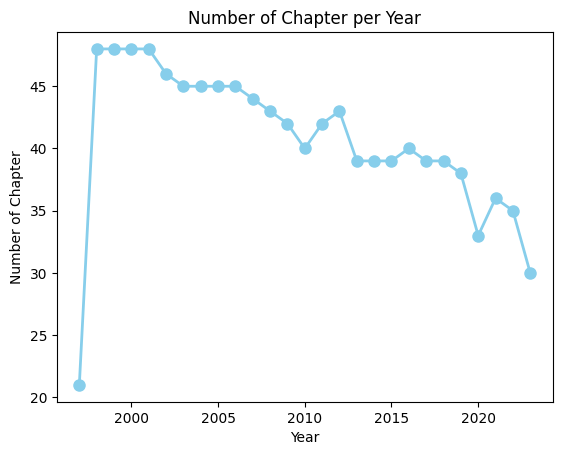

In [9]:
import matplotlib.pyplot as plt

year_counts = df['real_date'].dt.year.value_counts().sort_index()

# Plot the result as a bar plot
# year_counts.plot(kind='bar', color='skyblue', edgecolor='black')
year_counts.plot(kind='line', marker='o', color='skyblue', linestyle='-', linewidth=2, markersize=8)


# Set plot labels and title
plt.xlabel('Year')
plt.ylabel('Number of Chapter')
plt.title('Number of Chapter per Year')

# Show the plot
plt.show()


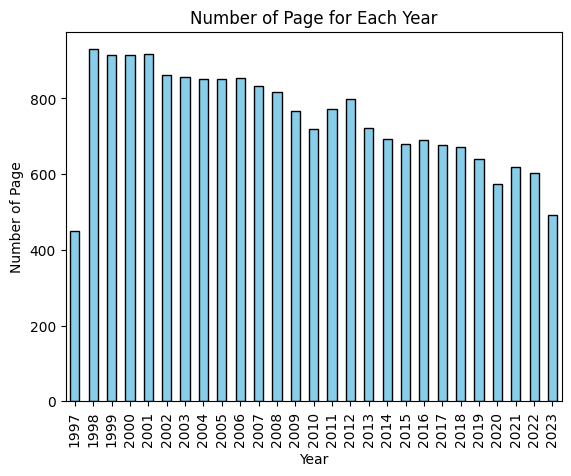

In [10]:
sum_per_year = df.groupby(df['real_date'].dt.year)['page'].sum()

# Plot the result as a bar plot
sum_per_year.plot(kind='bar', color='skyblue', edgecolor='black')

# Set plot labels and title
plt.xlabel('Year')
plt.ylabel('Number of Page')
plt.title('Number of Page for Each Year')

# Show the plot
plt.show()


In [11]:
total_page = df['page'].sum()
print(total_page)


20172


In [12]:
duration = df['real_date'].max() - df['real_date'].min()
print(duration)


9634 days 00:00:00


In [13]:
days = duration.total_seconds() // 86400
work_days = days * 5 // 7

print(f'Days: {days}')
print(f'Working: {work_days}')

print(f'Pages per day: {total_page / work_days}')


Days: 9634.0
Working: 6881.0
Pages per day: 2.9315506467083274


In [14]:
pages_counts = df['page'].value_counts()
counts_df = pd.DataFrame(pages_counts).reset_index()
counts_df.columns = ['Num Pages', 'Num Count']

print(counts_df)


    Num Pages  Num Count
0          19        690
1          17        306
2          15         45
3          21         15
4          20         15
5          18         15
6          13          6
7          23          4
8          24          2
9          53          1
10         29          1


In [15]:
selected_columns = ['chapter', 'name', 'page']
last_chapters = df.tail(10)[selected_columns]
print(last_chapters)


      chapter                                               name  page
1090     1091                                          Sentomaru    19
1091     1092                Kuma the Tyrant's Holy Land Rampage    17
1092     1093                                   Luffy vs. Kizaru    15
1093     1094  Five Elders, Godhead of Science & Defense, St....    19
1094     1095                      Better Off Dead in This World    15
1095     1096                                            Kumachi    17
1096     1097                                              Ginny    13
1097     1098                                     Bonney's Birth    15
1098     1099                                           Pacifist    17
1099     1100                                  Thank You, Bonney    17


In [16]:
df.iloc[0]['real_date']


Timestamp('1997-07-19 00:00:00')

    start   end  duration start_date   end_date
0       1   100  751 days 1997-07-19 1999-08-09
1     101   200  761 days 1999-08-23 2001-09-22
2     201   300  782 days 2001-10-01 2003-11-22
3     301   400  812 days 2003-12-01 2006-02-20
4     401   500  819 days 2006-02-27 2008-05-26
5     501   600  868 days 2008-06-02 2010-10-18
6     601   700  861 days 2010-10-25 2013-03-04
7     701   800  922 days 2013-03-11 2015-09-19
8     801   900  917 days 2015-09-28 2018-04-02
9     901  1000  994 days 2018-04-16 2021-01-04
10   1001  1100 1050 days 2021-01-18 2023-12-04


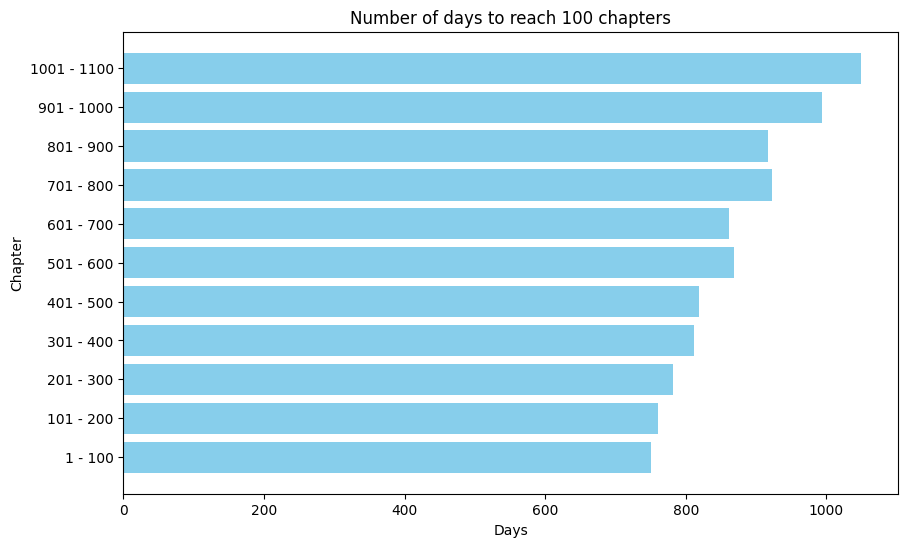

In [18]:
import plotly.express as px

i = 0
num_range_chapter = 100
duration_chapter = []
while i < len(df) - num_range_chapter + 1:
    start_date = df.iloc[i]['real_date']
    end_date = df.iloc[i + num_range_chapter - 1]['real_date']
    diff = end_date - start_date
    duration_chapter.append({
        'start': i + 1,
        'end': i + num_range_chapter,
        'duration': diff,
        'start_date': start_date,
        'end_date': end_date
    })
    i += num_range_chapter
df_duration = pd.DataFrame(duration_chapter)
print(df_duration)

# Create a new column for the bar labels (combination of two columns)
df_duration['BarLabel'] = df_duration['start'].astype(str) + ' - ' + df_duration['end'].astype(str)
df_duration['duration_days'] = df_duration['duration'].dt.days

# Plotting the horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bars = plt.barh(df_duration['BarLabel'], df_duration['duration_days'], color='skyblue')
plt.xlabel('Days')
plt.ylabel('Chapter')
plt.title('Number of days to reach 100 chapters')
plt.show()

# Display values on the bars
# for bar, value in zip(bars, df_duration['duration_days']):
#     plt.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, str(value), ha='left', va='center')

fig = px.bar(df_duration, x='duration_days', y='BarLabel', orientation='h', text='duration_days',
             labels={'BarLabel': 'Chapter', 'duration_days': 'Days'},
             title='Number of days to reach 100 chapters')

# Show the figure
fig.show()
